# Prédiction de l'attrition des employés

**Auteurs :** LOGBO Axelle, CAMARA Massaram

## Introduction

L'attrition,phenomene par lequel un individu resilie son contrat , représente un coût important pour une entreprise, recrutement, formation, perte de savoir-faire. L'objectif est de prédire si un employé risque de quitter l'entreprise à partir de son profil.

Il s'agit d'une classification binaire supervisée : la cible `attrition` vaut 1 si l'employé est parti, 0 sinon. Sur 1001 employés après nettoyage, 17,3 % sont partis, un déséquilibre de classes à prendre en compte.

Trois méthodes sont comparées : la régression logistique (discriminative), la LDA et la QDA (génératives). La démarche suit six étapes : nettoyage, exploration, modélisation, évaluation, interprétation, décision.

## Étape 0, Environnement de travail

Toutes les bibliothèques nécessaires sont importées ici, en une seule fois.

In [2]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Préparation et pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Évaluation
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix)

# VIF (multicolinéarité)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

print("Environnement prêt ")

Environnement prêt 


## Étape 1, Préparation des données

Le fichier source contient plusieurs problèmes typiques : valeurs numériques aberrantes, catégories incohérentes, types de données incorrects. Une inspection et un nettoyage préalables sont nécessaires.

### 1.1 Diagnostic du jeu de données brut

On inspecte le fichier brut : dimensions, types, valeurs manquantes, doublons, statistiques descriptives. Ce diagnostic permet d'identifier précisément les problèmes à corriger.

In [3]:
df = pd.read_csv("donnees_attrition_brut.csv", sep=";")

print("Dimensions :", df.shape)
print()
print(df.head())
print()
print(df.dtypes)
print()
print("Doublons :", df.duplicated().sum())
print()
print("Valeurs manquantes :")
print(df.isna().sum())
print()
print(df.describe())
print()
for col in ["departement", "teletravail"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

Dimensions : (1025, 10)

   age  anciennete_entreprise salaire_mensuel  distance_domicile_km  \
0   -5                    9.2         134 000                   6.7   
1   51                    0.8         444 000                  14.6   
2   46                    4.1       750   000                   5.0   
3   38                    1.7         470 000                   2.6   
4   38                    2.9         460 000                   0.5   

   nb_promotions_3ans  satisfaction_travail  heures_travail_hebdo departement  \
0                   0                   1.5                  38.0     Finance   
1                   0                   2.1                  48.0     Finance   
2                   0                   3.2                  56.0      Ventes   
3                   0                   NaN                  43.0      Ventes   
4                   0                   3.6                  35.0      VENTES   

  teletravail  attrition  
0       Total          1  
1     P

Le diagnostic a révélé plusieurs problèmes : âge hors bornes réalistes, satisfaction au travail hors échelle, salaire stocké en texte, catégories incohérentes. Chaque correction est appliquée ci-dessous.

In [4]:
# Age : bornes metier (18-70 ans, pour employes actifs)
df.loc[(df["age"] < 18) | (df["age"] > 70), "age"] = np.nan

print("=== Distribution complete de satisfaction_travail (comptage par valeur) ===")
print(df["satisfaction_travail"].value_counts().sort_index())

# Satisfaction travail : la distribution reelle est continue sur [0, 5] (voir value_counts).
# Les valeurs -1.0 et 8.0 sont des entiers isoles hors de cette plage continue,
# probablement des codes d'erreur/valeurs sentinelles plutot que de vraies mesures.
df.loc[df["satisfaction_travail"].isin([-1.0, 8.0]), "satisfaction_travail"] = np.nan

# Salaire : texte avec espaces irreguliers -> nombre
df["salaire_mensuel"] = pd.to_numeric(
    df["salaire_mensuel"].astype(str).str.replace(" ", "", regex=False).str.replace("\u202f", "", regex=False),
    errors="coerce"
)

# Categorielles : normalisation casse + espaces (bords ET milieu)
for col in ["departement", "teletravail"]:
    df[col] = df[col].astype(str).str.strip().str.upper().str.replace(" ", "", regex=False)
    df.loc[df[col] == "NAN", col] = np.nan

# Doublons (apres normalisation du texte)
df = df.drop_duplicates()

print("Dimensions finales :", df.shape)
print(df.isna().sum())


=== Distribution complete de satisfaction_travail (comptage par valeur) ===
satisfaction_travail
-1.0     4
 0.0     5
 1.0    14
 1.1     4
 1.2     6
 1.3     8
 1.4     9
 1.5    10
 1.6    11
 1.7    15
 1.8    13
 1.9    15
 2.0    13
 2.1    10
 2.2    32
 2.3    25
 2.4    24
 2.5    28
 2.6    29
 2.7    30
 2.8    23
 2.9    41
 3.0    43
 3.1    37
 3.2    48
 3.3    34
 3.4    38
 3.5    30
 3.6    45
 3.7    42
 3.8    37
 3.9    27
 4.0    32
 4.1    31
 4.2    20
 4.3    28
 4.4    20
 4.5    13
 4.6    21
 4.7    11
 4.8    12
 4.9    11
 5.0    44
 8.0     2
Name: count, dtype: int64
Dimensions finales : (1001, 10)
age                      10
anciennete_entreprise    40
salaire_mensuel           1
distance_domicile_km     30
nb_promotions_3ans        0
satisfaction_travail     36
heures_travail_hebdo     20
departement              50
teletravail              60
attrition                 0
dtype: int64


In [5]:
for val in df["departement"].dropna().unique():
    print(repr(val))

'FINANCE'
'VENTES'
'RH'
'IT'
'PRODUCTION'


Le nettoyage terminé, on explore les données : répartition de la cible, profil des employés selon leur statut, visualisation des différences.

## Étape 2, Exploration des données

Trois questions guident cette exploration : quelle est la proportion de départs ? quelles variables différencient les deux groupes ? les variables sont-elles corrélées entre elles ?

In [5]:
import seaborn as sns

# Probabilites a priori
print(df["attrition"].value_counts(normalize=True).round(3))

# Profil moyen par classe (variables numeriques)
profil = df.groupby("attrition").mean(numeric_only=True)
print(profil.round(2).T)

# Taux d'attrition par modalite categorielle
for col in ["departement", "teletravail"]:
    print(f"--- {col} ---")
    print(df.groupby(col)["attrition"].mean().round(3).sort_values(ascending=False))

attrition
0    0.827
1    0.173
Name: proportion, dtype: float64
attrition                      0          1
age                        41.17      37.80
anciennete_entreprise       4.41       2.53
salaire_mensuel        451771.46  377867.05
distance_domicile_km        7.15      11.94
nb_promotions_3ans          0.59       0.36
satisfaction_travail        3.34       2.73
heures_travail_hebdo       42.48      46.28
--- departement ---
departement
FINANCE       0.188
PRODUCTION    0.180
RH            0.176
IT            0.168
VENTES        0.155
Name: attrition, dtype: float64
--- teletravail ---
teletravail
JAMAIS     0.182
TOTAL      0.181
PARTIEL    0.155
Name: attrition, dtype: float64


Le taux d'attrition global est d'environ 17,3 %. Le profil moyen par classe montre des écarts notables sur `satisfaction_travail`, `distance_domicile_km`, `heures_travail_hebdo`, `anciennete_entreprise` et `salaire_mensuel`. `departement` et `teletravail` montrent des taux proches d'une modalité à l'autre, suggérant un pouvoir discriminant faible.

C:\Users\LENOVO X280\AppData\Local\Temp\ipykernel_21408\1492076637.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Reste", "Part"])


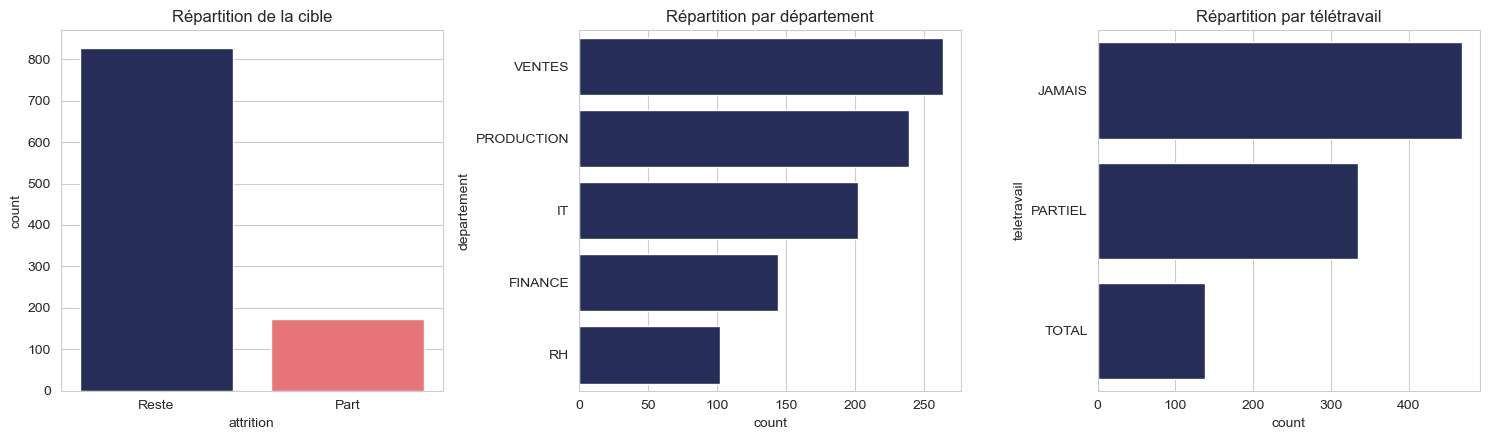

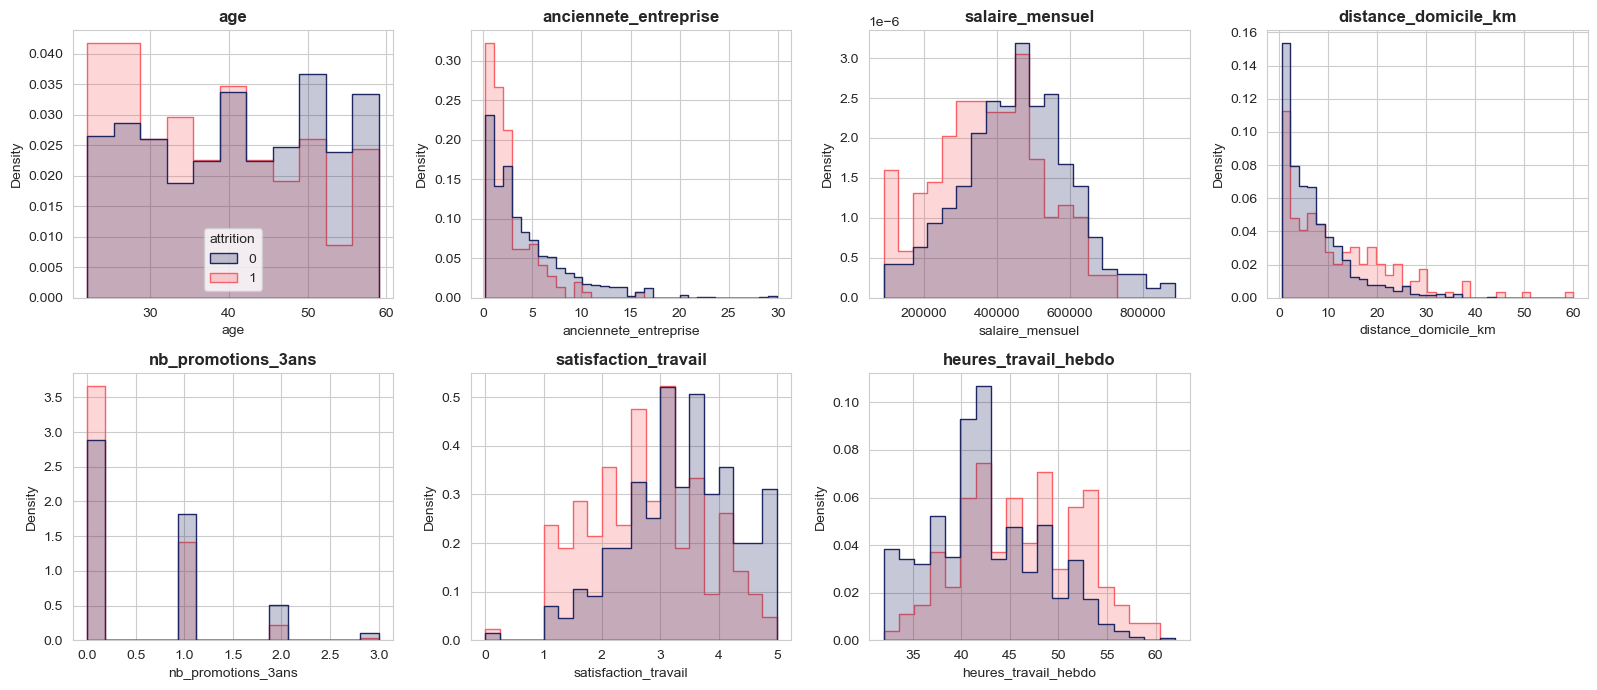

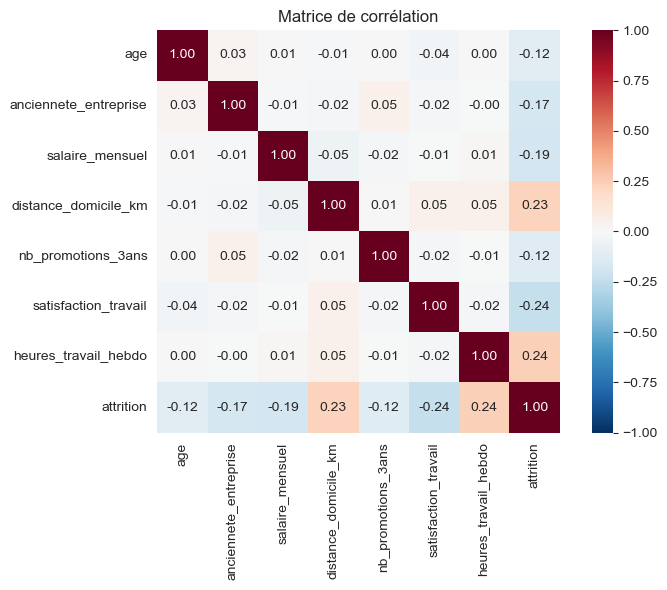

In [6]:
COULEUR_RESTE = "#1E2761"
COULEUR_PART  = "#F96167"
sns.set_style("whitegrid")

# --- Countplot : repartition cible + categorielles ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.countplot(x=df["attrition"], hue=df["attrition"], palette=[COULEUR_RESTE, COULEUR_PART],
              legend=False, ax=axes[0])
axes[0].set_xticklabels(["Reste", "Part"])
axes[0].set_title("Répartition de la cible")

sns.countplot(y=df["departement"], color=COULEUR_RESTE, order=df["departement"].value_counts().index, ax=axes[1])
axes[1].set_title("Répartition par département")

sns.countplot(y=df["teletravail"], color=COULEUR_RESTE, order=df["teletravail"].value_counts().index, ax=axes[2])
axes[2].set_title("Répartition par télétravail")

plt.tight_layout()
plt.show()

# --- Histogrammes par classe pour chaque variable numerique ---
num_cols = ["age","anciennete_entreprise","salaire_mensuel","distance_domicile_km",
            "nb_promotions_3ans","satisfaction_travail","heures_travail_hebdo"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="attrition", palette=[COULEUR_RESTE, COULEUR_PART],
                 element="step", stat="density", common_norm=False, ax=axes[i], legend=(i==0))
    axes[i].set_title(col, fontweight="bold")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

# --- Matrice de correlation ---
corr = df[num_cols + ["attrition"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

Les visualisations confirment les écarts observés : les distributions de `distance_domicile_km`, `satisfaction_travail` et `heures_travail_hebdo` se chevauchent moins entre classes que `age` ou `nb_promotions_3ans`. La matrice de corrélation ne montre pas de lien linéaire fort entre variables explicatives.

## Étape 3, Modélisation

Trois méthodes sont mises en œuvre et comparées : la régression logistique, la LDA et la QDA.

### 3.1 Préparation du pipeline

In [7]:
num_cols = ["age","anciennete_entreprise","salaire_mensuel","distance_domicile_km",
            "nb_promotions_3ans","satisfaction_travail","heures_travail_hebdo"]
cat_cols = ["departement","teletravail"]

X = df.drop(columns="attrition")
y = df["attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                       ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                       ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))]), cat_cols)
])

print("Train :", X_train.shape, " Test :", X_test.shape)

Train : (750, 9)  Test : (251, 9)


### 3.2 Vérification de la multicolinéarité (VIF)

La LDA et la QDA reposent sur l'inversion d'une matrice de covariance, une forte colinéarité rendrait cette inversion instable. Le VIF est calculé avec une constante ajoutée, nécessaire pour un calcul correct.

In [8]:
X_num_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(df[num_cols]), columns=num_cols)
X_const = sm.add_constant(X_num_imp)

vif = pd.DataFrame({
    "variable": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})
print(vif[vif["variable"] != "const"].sort_values("VIF", ascending=False).round(2))

                variable   VIF
4   distance_domicile_km  1.01
6   satisfaction_travail  1.00
2  anciennete_entreprise  1.00
5     nb_promotions_3ans  1.00
3        salaire_mensuel  1.00
7   heures_travail_hebdo  1.00
1                    age  1.00


**VIF** : toutes les variables ont un VIF entre 1,00 et 1,01, bien en dessous du seuil de 5. Il n'y a pas de multicolinéarité problématique. Ce résultat valide l'utilisation de la LDA et de la QDA.

### 3.3 Effet du paramètre C sur le sur-apprentissage

Le paramètre `C` contrôle l'intensité de la régularisation. On compare l'accuracy train et test pour différentes valeurs de C.

In [ ]:
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
train_acc, test_acc = [], []

for C in Cs:
    clf = Pipeline([("prep", preprocessor),
                     ("clf", LogisticRegression(C=C, max_iter=2000, class_weight="balanced", random_state=42))])
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(Cs, train_acc, "o-", color="#1E2761", label="Train")
ax.plot(Cs, test_acc, "o-", color="#F96167", label="Test")
ax.set_xscale("log")
ax.set_xlabel("C (échelle log)")
ax.set_ylabel("Accuracy")
ax.set_title("Effet de C sur le sur-apprentissage")
ax.legend()
plt.tight_layout()
plt.show()

**Effet de C** : à forte régularisation (C=0,001), le modèle est sous-ajusté, l'accuracy train (0,783) est inférieure à l'accuracy test (0,805). Quand C augmente, l'accuracy train se stabilise autour de 0,793-0,795, et l'accuracy test chute puis se stabilise autour de 0,781 à partir de C=0,1. Le croisement se situe autour de C=0,01.

### 3.4 Parcimonie, L1 vs L2

À régularisation égale (C=0,1), on compare le nombre de coefficients annulés par L1 et L2.

In [ ]:
Cs_path = np.logspace(-3, 2, 20)
coefs_path = []

for C in Cs_path:
    clf = Pipeline([("prep", preprocessor),
                     ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=C,
                                                 class_weight="balanced", max_iter=2000, random_state=42))])
    clf.fit(X_train, y_train)
    coefs_path.append(clf.named_steps["clf"].coef_[0])

coefs_path = np.array(coefs_path)
feature_names = preprocessor.fit(X_train).get_feature_names_out()

plt.figure(figsize=(9,6))
for j, nom in enumerate(feature_names):
    plt.plot(np.log10(Cs_path), coefs_path[:, j], label=nom)
plt.xlabel("log10(C)  →  gauche = forte régularisation | droite = faible régularisation")
plt.ylabel("Valeur du coefficient")
plt.axhline(0, color="black", lw=0.5)
plt.legend(fontsize=7, loc="center left", bbox_to_anchor=(1,0.5))
plt.title("Chemin de régularisation (Lasso)")
plt.tight_layout()
plt.show()

**Chemin de régularisation** : `heures_travail_hebdo` (jusqu'à +0,85) et `distance_domicile_km` (+0,62) sont des facteurs de risque, `teletravail_PARTIEL` (jusqu'à -1,05) et `satisfaction_travail` sont protecteurs. Ces variables se stabilisent dès C environ 0,1 à 1. `age` et `departement_RH` restent proches de zéro, confirmant leur faible pouvoir prédictif.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_log = Pipeline([("prep", preprocessor),
                      ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])
grid_log = GridSearchCV(pipe_log,
                         {"clf__C":[0.001,0.01,0.1,1,10,100], "clf__penalty":["l1","l2"], "clf__solver":["liblinear"]},
                         cv=cv, scoring="roc_auc")
grid_log.fit(X_train, y_train)
print("Logistique - meilleurs params :", grid_log.best_params_, " AUC CV :", round(grid_log.best_score_,3))

pipe_qda = Pipeline([("prep", preprocessor), ("clf", QuadraticDiscriminantAnalysis())])
grid_qda = GridSearchCV(pipe_qda, {"clf__reg_param":[0.0,0.1,0.3,0.5,0.7,1.0]}, cv=cv, scoring="roc_auc")
grid_qda.fit(X_train, y_train)
print("QDA - meilleur reg_param :", grid_qda.best_params_, " AUC CV :", round(grid_qda.best_score_,3))

Logistique - meilleurs params : {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}  AUC CV : 0.851
QDA - meilleur reg_param : {'clf__reg_param': 1.0}  AUC CV : 0.847


**GridSearchCV** : la validation croisée retient C=0,01 (AUC CV = 0,851) pour la régression logistique, cohérent avec la zone de croisement observée sur la courbe d'accuracy.

### 3.6 Modèles finaux

Les trois modèles sont regroupés dans un dictionnaire : logistique et QDA avec leurs meilleurs réglages issus du GridSearchCV, LDA avec ses paramètres par défaut.

In [11]:
modeles = {
    "Logistique": grid_log.best_estimator_,
    "LDA": Pipeline([("prep", preprocessor), ("clf", LinearDiscriminantAnalysis())]).fit(X_train, y_train),
    "QDA": grid_qda.best_estimator_,
}
print("Les 3 modeles sont entraines.")

Les 3 modeles sont entraines.


**QDA** : le meilleur `reg_param` trouvé est 1,0 (AUC CV = 0,847), ce qui ramène QDA à une covariance partagée entre classes, proche du comportement de la LDA. L'hypothèse de covariance commune semble mieux adaptée ici.

## Étape 4, Évaluation

### 4.1 Validation croisée comparative

In [12]:
for nom, modele in modeles.items():
    scores = cross_val_score(modele, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{nom:12s} AUC CV : {scores.mean():.3f} +/- {scores.std():.3f}")

Logistique   AUC CV : 0.851 +/- 0.030
LDA          AUC CV : 0.841 +/- 0.029
QDA          AUC CV : 0.847 +/- 0.033


Les trois modèles obtiennent une AUC proche en validation croisée (Logistique 0,851, QDA 0,847, LDA 0,841). La régression logistique est légèrement en tête.

### 4.2 Prédictions sur l'ensemble de test

Les prédictions sont calculées une fois pour chaque modèle, puis réutilisées pour la matrice de confusion et la courbe ROC.

In [13]:
predictions = {}
for nom, modele in modeles.items():
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    predictions[nom] = (y_pred, y_proba)

### 4.3 Matrices de confusion et métriques par modèle

In [ ]:
for nom, (y_pred, y_proba) in predictions.items():
    print(f"--- {nom} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=["Reste","Part"], zero_division=0))
    print("AUC test :", round(roc_auc_score(y_test, y_proba), 3))
    print()

Malgré des AUC proches (Logistique 0,891, LDA 0,891, QDA 0,884), les comportements diffèrent au seuil de 0,5. La logistique détecte le plus de départs (rappel 0,84) mais génère plus de fausses alertes (précision 0,38). LDA et QDA sont plus précises (0,88 et 0,90) mais ratent la majorité des départs (rappel 0,33 et 0,21).

### 4.4 Courbes ROC comparées

In [ ]:
plt.figure(figsize=(7,6))
couleurs = {"Logistique": "#1E2761", "LDA": "#F96167", "QDA": "#2C5F2D"}

for nom, (y_pred, y_proba) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nom} (AUC={auc:.3f})", color=couleurs[nom])

plt.plot([0,1],[0,1], "--", color="gray", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC, comparaison des 3 modeles")
plt.legend()
plt.tight_layout()
plt.show()

Les trois courbes ROC sont quasiment superposées, confirmant un pouvoir de classement global similaire. Le choix final dépendra de l'interprétabilité et de l'arbitrage précision/rappel.

## Étape 5, Interprétation

### 5.1 Odds ratios (régression logistique)

Les coefficients standardisés sont convertis en odds ratios (e^coef), lus pour une augmentation d'un écart-type.

In [16]:
best_log = modeles["Logistique"]
feature_names = best_log.named_steps["prep"].get_feature_names_out()
coefs = best_log.named_steps["clf"].coef_[0]

odds_ratios = pd.Series(np.exp(coefs), index=feature_names).sort_values(ascending=False)
print(odds_ratios.round(3))

num__heures_travail_hebdo      1.472
num__distance_domicile_km      1.368
cat__departement_PRODUCTION    0.981
cat__teletravail_TOTAL         0.971
cat__departement_RH            0.969
cat__departement_VENTES        0.958
cat__departement_IT            0.941
cat__teletravail_PARTIEL       0.938
num__age                       0.862
num__nb_promotions_3ans        0.780
num__salaire_mensuel           0.708
num__satisfaction_travail      0.702
num__anciennete_entreprise     0.697
dtype: float64


`heures_travail_hebdo` (OR=1,47) et `distance_domicile_km` (OR=1,37) sont les facteurs de risque dominants. `satisfaction_travail`, `anciennete_entreprise` et `salaire_mensuel` (OR autour de 0,70) sont les facteurs protecteurs les plus forts. `departement` et `teletravail` ont des odds ratios proches de 1, confirmant leur faible pouvoir prédictif.

### 5.2 Profil par classe

LDA et QDA n'offrent pas d'odds ratios ni de p-values, leur interprétation passe par la comparaison des moyennes par classe.

In [17]:
print(df.groupby("attrition").mean(numeric_only=True).round(2).T)

attrition                      0          1
age                        41.17      37.80
anciennete_entreprise       4.41       2.53
salaire_mensuel        451771.46  377867.05
distance_domicile_km        7.15      11.94
nb_promotions_3ans          0.59       0.36
satisfaction_travail        3.34       2.73
heures_travail_hebdo       42.48      46.28


Les écarts de moyennes confirment les odds ratios : distance domicile-travail plus élevée pour les partants (11,94 vs 7,15 km), plus d'heures travaillées (46,28 vs 42,48 h), satisfaction plus faible (2,73 vs 3,34), ancienneté plus courte (2,53 vs 4,41 ans) et salaire inférieur (377 867 vs 451 771).

### 5.3 Coefficients de la LDA

La LDA produit aussi des coefficients linéaires, interprétables comme une régression logistique, mais sans le cadre probabiliste des odds ratios.

In [18]:
best_lda = modeles["LDA"]
coefs_lda = pd.Series(best_lda.named_steps["clf"].coef_[0], index=feature_names).sort_values(ascending=False)
print(coefs_lda.round(3))

num__heures_travail_hebdo      0.772
num__distance_domicile_km      0.746
cat__departement_PRODUCTION    0.230
cat__departement_IT            0.126
cat__teletravail_TOTAL         0.090
cat__departement_VENTES        0.042
cat__teletravail_PARTIEL      -0.065
cat__departement_RH           -0.106
num__age                      -0.314
num__nb_promotions_3ans       -0.469
num__anciennete_entreprise    -0.601
num__salaire_mensuel          -0.641
num__satisfaction_travail     -0.762
dtype: float64


Les coefficients de la LDA suivent la même hiérarchie que les odds ratios : `heures_travail_hebdo` et `distance_domicile_km` en tête côté risque, `satisfaction_travail`, `salaire_mensuel` et `anciennete_entreprise` en tête côté protection.

### 5.4 Comparaison logistique vs LDA

Les deux jeux de coefficients sont comparés pour vérifier la cohérence des variables importantes.

In [19]:
comparaison = pd.DataFrame({
    "Odds ratio (Logistique)": odds_ratios,
    "Coefficient (LDA)": coefs_lda
})
print(comparaison.round(3))

                             Odds ratio (Logistique)  Coefficient (LDA)
cat__departement_IT                            0.941              0.126
cat__departement_PRODUCTION                    0.981              0.230
cat__departement_RH                            0.969             -0.106
cat__departement_VENTES                        0.958              0.042
cat__teletravail_PARTIEL                       0.938             -0.065
cat__teletravail_TOTAL                         0.971              0.090
num__age                                       0.862             -0.314
num__anciennete_entreprise                     0.697             -0.601
num__distance_domicile_km                      1.368              0.746
num__heures_travail_hebdo                      1.472              0.772
num__nb_promotions_3ans                        0.780             -0.469
num__salaire_mensuel                           0.708             -0.641
num__satisfaction_travail                      0.702            

Le tableau confirme un accord quasi parfait entre les deux méthodes sur le sens de l'effet, sauf pour `departement_RH` et `teletravail_PARTIEL`, où les coefficients restent proches de zéro. Cette convergence renforce la confiance dans les variables clés : `heures_travail_hebdo`, `distance_domicile_km`, `satisfaction_travail`, `salaire_mensuel` et `anciennete_entreprise`.

Les résultats permettent de choisir et justifier une méthode finale.

## Étape 6, Décision

### Synthèse

| Modèle | AUC test | Rappel (Part) | Précision (Part) | Interprétabilité |
|---|---|---|---|---|
| Logistique | 0,891 | 0,84 | 0,38 | Odds ratios, p-values |
| LDA | 0,891 | 0,33 | 0,88 | Coefficients, sans p-values |
| QDA | 0,884 | 0,21 | 0,90 | Aucune |

Les trois modèles ont un pouvoir de classement similaire (AUC 0,884 à 0,891), et le VIF confirme l'absence de multicolinéarité. La différence se joue sur le compromis précision/rappel : la logistique détecte 84 % des départs réels, contre 33 % pour la LDA et 21 % pour la QDA. QDA n'apporte pas de gain par rapport à LDA, son meilleur réglage la ramène à un comportement proche de la LDA. Les coefficients de la LDA et les odds ratios de la logistique s'accordent sur les mêmes variables clés.

### Décision

La régression logistique est retenue. Dans un contexte RH, un départ non anticipé coûte plus cher qu'une fausse alerte, ce qui justifie de privilégier le rappel. Elle permet aussi une interprétation quantifiée via les odds ratios.

### Recommandations

- Porter attention aux employés combinant charge horaire élevée et trajet domicile-travail long.
- Renforcer le suivi de la satisfaction au travail et les politiques salariales pour les employés récents.
- Ajuster le seuil de décision selon le budget RH disponible pour le suivi préventif.

## Conclusion

Ce projet a permis de construire un système de prédiction de l'attrition avec une démarche rigoureuse : nettoyage justifié, exploration guidant la modélisation, comparaison de trois méthodes, évaluation par validation croisée et test isolé, interprétation croisée. La régression logistique est retenue pour sa performance en rappel et sa capacité d'explication.